# Definindo o problema

Estudo sobre a aplicação de Vision Transformers (ViT) no contexto de bioinformática e processamento de sequências biológicas.

# Vit - Vision Transformer

Vit é um dos principais modelos da atualidade pois traz algumas melhorias significativas como: Melhor desempenho em tarefas onde as relações globais importam (segmentação de imagens), escala melhor e em geral tem performado melhor.

Existe um reposiório com os principais modelos de ViT da Literatura: https://github.com/lucidrains/vit-pytorch/tree/main, esse repositório é incrivelmente detalhado e muito completo.

Vamos usar o mesmo conjunto de dados de câncer para predizer se é benign ou malignant e o modelo Vision Transformer for Small Datasets no repositório

### Importando as Bibliotecas Necessárias

In [ ]:
# Importando os dados
from google.colab import drive
import os # Biblioteca padrão do Python para interação com o sistema operacional, permitindo manipular arquivos, pastas e caminhos de forma simples.
import numpy as np # Biblioteca fundamental para computação científica em Python. Permite a manipulação eficiente de arrays, matrizes e a realização de diversas operações matemáticas complexas.
import torch # Uma das principais bibliotecas para construção e treinamento de modelos de Deep Learning. Oferece suporte para computação em GPU e diferenciação automática para cálculo de gradientes.

drive.mount('/content/drive')

# Definindo variável ou realizando operação: pasta
pasta = "/content/drive/My Drive/Curso_Xmeeting_2026/Data"
os.chdir(pasta)

print("Diretório atual:", os.getcwd())

Mounted at /content/drive
Diretório atual: /content/drive/My Drive/Curso_Xmeeting_2026/Data


In [ ]:
# Importa módulos essenciais do PyTorch para carregar e transformar conjuntos de dados de imagens
from torchvision import datasets, transforms # Módulo do PyTorch para manipulação de dados de visão computacional, oferecendo classes e funções para carregar, transformar e pré-processar imagens.
from torch.utils.data import DataLoader, random_split # DataLoader: Facilita o carregamento de dados em lotes (batches) e a iteração sobre eles durante o treinamento.

# Define o tamanho padrão para o redimensionamento das imagens (largura e altura iguais)
# Definindo variável ou realizando operação: imgSize
imgSize = 224

# Define uma sequência de transformações a serem aplicadas às imagens:
# 1. Redimensiona cada imagem para 224x224 pixels
# 2. Converte a imagem (normalmente PIL ou numpy) em um tensor PyTorch
# Definindo variável ou realizando operação: transformer
transformer = transforms.Compose([
    transforms.Resize((imgSize, imgSize)),
    transforms.ToTensor()
])

# Caminho onde estão as imagens de treino
path = '/content/drive/MyDrive/Curso_Xmeeting_2026/Data/Dataset_cancer/train'
# Caminho onde estão as imagens de teste
testPath = '/content/drive/MyDrive/Curso_Xmeeting_2026/Data/Dataset_cancer/test'

# Carrega as imagens de treino, aplicando as transformações definidas
trainData = datasets.ImageFolder(root=path, transform=transformer)
# Carrega as imagens de teste, aplicando as mesmas transformações
testData = datasets.ImageFolder(root=testPath, transform=transformer)

# --------------------------------------------------------------
# Divide o conjunto de treino em dois subconjuntos:
# - 80% para treino
# - 20% para validação
# Isso ajuda a verificar se o modelo está aprendendo corretamente
# sem sobreajuste (overfitting) nos dados de treino.
# --------------------------------------------------------------
train_size = int(0.8 * len(trainData))  # Calcula 80% do tamanho total
val_size = len(trainData) - train_size  # O restante (20%) vai para validação
trainSubset, valSubset = random_split(trainData, [train_size, val_size])

# Cria DataLoaders que gerenciam os lotes (batches) de dados para cada fase:
# - shuffle=True para treino embaralhar os dados (boa prática)
# - shuffle=False para validação e teste manterem ordem consistente
trainLoader = DataLoader(trainSubset, batch_size=32, shuffle=True)
valLoader = DataLoader(valSubset, batch_size=32, shuffle=False)
testLoader = DataLoader(testData, batch_size=32, shuffle=False)

# Exibe quantas imagens há em cada subconjunto
print(f"Tamanho do treino: {len(trainSubset)}")
print(f"Tamanho da validação: {len(valSubset)}")
print(f"Tamanho do teste: {len(testData)}")

Tamanho do treino: 9503
Tamanho da validação: 2376
Tamanho do teste: 11879


In [ ]:
# --------------------------------------------------------------
# Análise da distribuição das classes no conjunto de treino
# Isso é importante para saber se o dataset está balanceado.
# --------------------------------------------------------------
from collections import Counter  # Para contar quantas imagens há por classe

# Cria uma lista com os rótulos reais das imagens que estão no subconjunto de treino
train_labels = [trainData.targets[i] for i in trainSubset.indices]

# Conta quantas imagens existem por classe
class_counts = Counter(train_labels)
class_names = trainData.classes  # Nomes das classes (extraídos automaticamente das pastas)

# Exibe o número de imagens por classe
print("Distribuição das classes no conjunto de treino:")
for i, class_name in enumerate(class_names):
    print(f"{class_name}: {class_counts[i]} imagens")

Distribuição das classes no conjunto de treino:
Benign: 5053 imagens
Malignant: 4450 imagens


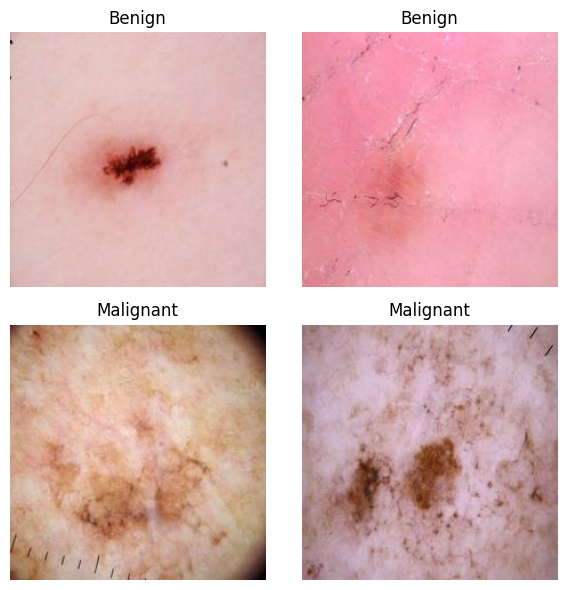

In [ ]:
import matplotlib.pyplot as plt  # Biblioteca para visualização gráfica

# Função para mostrar amostras de imagens do dataset
def show_samples(dataset):
    """
    Função: show_samples
    Descrição: Função responsável por executar a lógica de show_samples dentro do contexto deste notebook, contribuindo para o processamento ou análise dos dados.
    """
    class_names = dataset.classes  # Obtém os nomes das classes
    fig, axes = plt.subplots(2, 2, figsize=(6, 6))  # Cria uma grade de 2x2 para exibir imagens

    shown = [0, 0]  # Contador para garantir que no máximo 2 imagens de cada classe serão mostradas

    for img, label in dataset:  # Itera por cada imagem e seu respectivo rótulo
        if shown[label] < 2:  # Se ainda não mostramos 2 imagens dessa classe
            ax = axes[label][shown[label]]  # Escolhe a posição no grid (eixo X e Y)
            img = img.permute(1, 2, 0)  # Converte a imagem de (C, H, W) para (H, W, C), que o matplotlib entende
            ax.imshow(img.numpy())  # Mostra a imagem convertida para array numpy
            ax.axis("off")  # Esconde os eixos da imagem
            ax.set_title(class_names[label])  # Coloca o nome da classe como título
            shown[label] += 1  # Incrementa o número de imagens mostradas dessa classe

        # Quando já mostramos 2 imagens de cada classe, paramos
        if all(s == 2 for s in shown):
            break

    plt.tight_layout()  # Ajusta os espaçamentos entre os gráficos
    plt.show()  # Exibe a figura com as imagens

# Chama a função para mostrar amostras do conjunto de treino
show_samples(trainData)

In [ ]:
import torch.nn.functional as F # Módulo funcional do PyTorch que contém funções de ativação, perda, convolução e outras operações comuns usadas em redes neurais.
from torch import nn # Módulo do PyTorch que contém classes para construir camadas de redes neurais, como Linear, Conv2d, LayerNorm, Dropout, entre outras. Facilita a criação de modelos complexos de Deep Learning.

# Einops facilita a reorganização (reshape) de tensores de maneira mais intuitiva
from einops import rearrange, repeat # Biblioteca utilizada para manipular a forma dos tensores de maneira mais legível e intuitiva, especialmente útil em modelos de atenção e Transformers.
from einops.layers.torch import Rearrange # Facilita a criação de camadas que reorganizam os tensores de forma específica, muito útil para preparar os dados para camadas de atenção e feedforward em Transformers.

# ----------------------------------------------------
# Função auxiliar que garante que a variável seja uma tupla (par)
# Se o input for um número, ele transforma em (n, n)
# Se já for uma tupla, retorna como está
# Isso é útil para tratar tamanhos de imagens e patches uniformemente
# ----------------------------------------------------
def pair(t):
  """
  Função: pair
  Descrição: Função responsável por executar a lógica de pair dentro do contexto deste notebook, contribuindo para o processamento ou análise dos dados.
  """
  return t if isinstance(t, tuple) else (t, t)

# ----------------------------------------------------
# Classe FeedForward — bloco de rede neural densa usado dentro do Transformer
# Aplica normalização, camadas lineares, ativação GELU e dropout
# ----------------------------------------------------
class FeedForward(nn.Module):
  """
  Definição da classe FeedForward.
  Esta classe encapsula a lógica do modelo ou da estrutura de dados que estamos utilizando.
  """
  def __init__(self, dim, hidden_dim, dropout = 0.):
    """
    Função: __init__
    Descrição: Método construtor da classe. Responsável por inicializar os parâmetros fundamentais, como pesos, biases e a estrutura das camadas da rede neural.
    """
    super().__init__()
    self.net = nn.Sequential(
        nn.LayerNorm(dim),         # Normaliza os valores de entrada
        nn.Linear(dim, hidden_dim),# Primeira camada densa que aumenta a dimensionalidade
        nn.GELU(),                 # Ativação GELU (mais suave que ReLU)
        nn.Dropout(dropout),       # Reduz overfitting
        nn.Linear(hidden_dim, dim),# Reduz de volta para o tamanho original
        nn.Dropout(dropout)        # Dropout novamente
    )

    def forward(self, x):
      """
      Função: forward
      Descrição: Define o fluxo de dados (forward pass) através das camadas da rede, processando a entrada para gerar as predições ou logits de saída.
      """
      return self.net(x)

# ----------------------------------------------------
# Classe LSA (Locality Self-Attention)
# Módulo de atenção com normalização e projeção para QKV (Query, Key, Value)
# Aplica máscara para evitar autoatenção (diagonal)
# ----------------------------------------------------
class LSA(nn.Module):
  """
  Definição da classe LSA.
  Esta classe encapsula a lógica do modelo ou da estrutura de dados que estamos utilizando.
  """
  def __init__(self, dim, heads = 8, dim_head = 64, dropout = 0.):
    """
    Função: __init__
    Descrição: Método construtor da classe. Responsável por inicializar os parâmetros fundamentais, como pesos, biases e a estrutura das camadas da rede neural.
    """
    super().__init__()
    inner_dim = dim_head * heads       # Dimensão total considerando todas as "cabeças"
    self.heads = heads
    self.temperature = nn.Parameter(torch.log(torch.tensor(dim_head ** -0.5))) # Escala para atenção

    self.norm = nn.LayerNorm(dim)        # Normalização antes da atenção
    self.attend = nn.Softmax(dim = -1)   # Função softmax ao longo da última dimensão (atenção)
    self.dropout = nn.Dropout(dropout)   # Dropout após atenção

    self.to_qkv = nn.Linear(dim, inner_dim * 3, bias = False)  # Projeção linear para Q, K, V

    self.to_out = nn.Sequential(
        nn.Linear(inner_dim, dim),      # Projeta de volta para dimensão original
        nn.Dropout(dropout)
    )

  def forward(self, x):
    """
    Função: forward
    Descrição: Define o fluxo de dados (forward pass) através das camadas da rede, processando a entrada para gerar as predições ou logits de saída.
    """
    x = self.norm(x)                              # Normaliza entrada
    qkv = self.to_qkv(x).chunk(3, dim = -1)       # Divide em 3 partes: Q, K, V
    q, k, v = map(lambda t: rearrange(t, 'b n (h d) -> b h n d', h = self.heads), qkv)

    # Produto escalar entre Q e K transposta, escalado por temperatura
    dots = torch.matmul(q, k.transpose(-1, -2)) * self.temperature.exp()

    # Máscara para bloquear autoatenção (atenção em si mesmo)
    mask = torch.eye(dots.shape[-1], device = dots.device, dtype = torch.bool)
    mask_value = -torch.finfo(dots.dtype).max
    dots = dots.masked_fill(mask, mask_value)

    # Aplica softmax para obter pesos de atenção
    attn = self.attend(dots)
    attn = self.dropout(attn)

    # Multiplica atenção pelos valores (V)
    out = torch.matmul(attn, v)
    out = rearrange(out, 'b h n d -> b n (h d)')  # Junta cabeças
    return self.to_out(out)

# ----------------------------------------------------
# Transformer — empilha camadas de autoatenção e feedforward
# Cada camada adiciona a saída à entrada (residual connection)
# ----------------------------------------------------
class Transformer(nn.Module):
  """
  Definição da classe Transformer.
  Esta classe encapsula a lógica do modelo ou da estrutura de dados que estamos utilizando.
  """
  def __init__(self, dim, depth, heads, dim_head, mlp_dim, dropout = 0.):
    """
    Função: __init__
    Descrição: Método construtor da classe. Responsável por inicializar os parâmetros fundamentais, como pesos, biases e a estrutura das camadas da rede neural.
    """
    super().__init__()
    self.layers = nn.ModuleList([])  # Lista de camadas do Transformer
    for _ in range(depth):
        self.layers.append(nn.ModuleList([
            LSA(dim, heads = heads, dim_head = dim_head, dropout = dropout),
            FeedForward(dim, mlp_dim, dropout = dropout)
        ]))

  def forward(self, x):
    """
    Função: forward
    Descrição: Define o fluxo de dados (forward pass) através das camadas da rede, processando a entrada para gerar as predições ou logits de saída.
    """
    for attn, ff in self.layers:
        x = attn(x) + x     # Atenção + conexão residual
        x = ff(x) + x       # FeedForward + conexão residual
    return x

# ----------------------------------------------------
# SPT — Shifted Patch Tokenization
# Extrai patches de imagem e inclui versões "deslocadas" da imagem para adicionar contexto local
# ----------------------------------------------------
class SPT(nn.Module):
  """
  Definição da classe SPT.
  Esta classe encapsula a lógica do modelo ou da estrutura de dados que estamos utilizando.
  """
  def __init__(self, *, dim, patch_size, channels = 3):
    """
    Função: __init__
    Descrição: Método construtor da classe. Responsável por inicializar os parâmetros fundamentais, como pesos, biases e a estrutura das camadas da rede neural.
    """
    super().__init__()
    patch_dim = patch_size * patch_size * 5 * channels  # 5 canais: imagem + 4 deslocamentos

    self.to_patch_tokens = nn.Sequential(
        Rearrange('b c (h p1) (w p2) -> b (h w) (p1 p2 c)', p1 = patch_size, p2 = patch_size),  # Divide imagem em patches
        nn.LayerNorm(patch_dim),   # Normaliza o vetor de cada patch
        nn.Linear(patch_dim, dim)  # Projeta para dimensão de entrada do Transformer
    )

  def forward(self, x):
    """
    Função: forward
    Descrição: Define o fluxo de dados (forward pass) através das camadas da rede, processando a entrada para gerar as predições ou logits de saída.
    """
    # Define deslocamentos para cima, baixo, esquerda e direita
    shifts = ((1, -1, 0, 0), (-1, 1, 0, 0), (0, 0, 1, -1), (0, 0, -1, 1))
    shifted_x = list(map(lambda shift: F.pad(x, shift), shifts))  # Aplica padding (deslocamentos)
    x_with_shifts = torch.cat((x, *shifted_x), dim = 1)  # Junta canais original + deslocados
    return self.to_patch_tokens(x_with_shifts)

# ----------------------------------------------------
# ViT (Vision Transformer) com Shifted Patch Tokenization (SPT)
# Implementa um modelo Transformer para classificação de imagens
# ----------------------------------------------------
class ViT(nn.Module):
  """
  Definição da classe ViT.
  Esta classe encapsula a lógica do modelo ou da estrutura de dados que estamos utilizando.
  """
  def __init__(self, *, image_size, patch_size, num_classes, dim, depth, heads, mlp_dim,
                pool = 'cls', channels = 3, dim_head = 64, dropout = 0., emb_dropout = 0.):
    """
    Função: __init__
    Descrição: Método construtor da classe. Responsável por inicializar os parâmetros fundamentais, como pesos, biases e a estrutura das camadas da rede neural.
    """
    super().__init__()
    image_height, image_width = pair(image_size)
    patch_height, patch_width = pair(patch_size)

    # Verifica se a imagem pode ser dividida igualmente em patches
    assert image_height % patch_height == 0 and image_width % patch_width == 0, 'Image dimensions must be divisible by the patch size.'

    num_patches = (image_height // patch_height) * (image_width // patch_width)
    patch_dim = channels * patch_height * patch_width
    assert pool in {'cls', 'mean'}, 'pool type must be either cls (cls token) or mean (mean pooling)'

    self.to_patch_embedding = SPT(dim = dim, patch_size = patch_size, channels = channels)  # Tokenização com deslocamentos

    # Adiciona embeddings de posição e um token de classificação
    self.pos_embedding = nn.Parameter(torch.randn(1, num_patches + 1, dim))  # Posição
    self.cls_token = nn.Parameter(torch.randn(1, 1, dim))  # Token especial para classificação
    self.dropout = nn.Dropout(emb_dropout)

    # Bloco Transformer com múltiplas camadas
    self.transformer = Transformer(dim, depth, heads, dim_head, mlp_dim, dropout)

    self.pool = pool  # Tipo de pooling: usar o token cls ou média dos tokens
    self.to_latent = nn.Identity()  # Placeholder (pode ser alterado se necessário)

    # Cabeça MLP final: transforma o vetor em classes
    self.mlp_head = nn.Sequential(
        nn.LayerNorm(dim),
        nn.Linear(dim, num_classes)
    )

  def forward(self, img):
    """
    Função: forward
    Descrição: Define o fluxo de dados (forward pass) através das camadas da rede, processando a entrada para gerar as predições ou logits de saída.
    """
    x = self.to_patch_embedding(img)  # Divide a imagem em patches e projeta
    b, n, _ = x.shape

    cls_tokens = repeat(self.cls_token, '() n d -> b n d', b = b)  # Replica token de classificação
    x = torch.cat((cls_tokens, x), dim=1)  # Adiciona token ao início
    x += self.pos_embedding[:, :(n + 1)]  # Adiciona informação de posição
    x = self.dropout(x)

    x = self.transformer(x)  # Passa pelas camadas do Transformer

    # Seleciona o vetor final para classificação
    x = x.mean(dim = 1) if self.pool == 'mean' else x[:, 0]  # Média dos tokens ou apenas o token cls

    x = self.to_latent(x)
    return self.mlp_head(x)  # Saída com as probabilidades para cada classe

In [ ]:
# Define o modelo Vision Transformer
model = ViT(
    image_size = 224,       # Tamanho da imagem (altura e largura)
    patch_size = 16,        # Tamanho dos patches extraídos
    num_classes = 2,        # Número de classes (binária)
    dim = 512,              # Dimensão do vetor de embedding dos patches
    depth = 4,              # Número de camadas Transformer
    heads = 4,              # Número de cabeças de atenção
    mlp_dim = 252,          # Dimensão interna do MLP dentro do Transformer
    dropout = 0.1,          # Dropout nas camadas do Transformer
    emb_dropout = 0.1       # Dropout aplicado após embedding dos patches
)

In [ ]:
import torch.optim as optim # Módulo do PyTorch que contém otimizadores para atualizar os pesos do modelo durante o treinamento, como SGD, Adam, RMSprop, entre outros.

criterion = nn.CrossEntropyLoss()                                      # Função de perda apropriada para classificação multiclasse
optimizer = optim.Adam(model.parameters(), lr = 0.001)                 # Otimizador Adam com learning rate 0.001
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')  # Usa GPU se disponível

# Listas para salvar métricas
trainLosses = []
valLosses = []
valAccs = []

# Número de épocas de treino
epochs = 3
model.to(device)  # Move o modelo para GPU (ou CPU se não tiver)

# Loop de treino
for epoch in range(epochs):
    model.train()               # Modo treino: ativa dropout, batchnorm etc.
    runningLoss = 0.0           # Acumula perda por época

    for inputs, labels in trainLoader:
        inputs, labels = inputs.to(device), labels.to(device)  # Move dados para o mesmo dispositivo do modelo

        optimizer.zero_grad()          # Zera os gradientes anteriores
        outputs = model(inputs)        # Passa os inputs pelo modelo
        loss = criterion(outputs, labels)  # Calcula a perda
        runningLoss += loss.item()     # Soma a perda ao acumulador

        loss.backward()                # Calcula os gradientes
        optimizer.step()               # Atualiza os pesos


    trainLoss = runningLoss / len(trainLoader)  # Média da perda da época
    print(f'Epoch {epoch + 1}/{epochs} - Training Loss : {trainLoss:.2f}')
    trainLosses.append(trainLoss)

    # Avaliação no conjunto de validação
    model.eval()                       # Modo avaliação: desativa dropout etc.
    with torch.no_grad():             # Não calcula gradientes nessa parte (mais leve)
        valLoss = 0.0
        correct = total = 0

        for inputs, labels in valLoader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)               # Forward no modelo
            loss = criterion(outputs, labels)     # Calcula perda de validação
            valLoss += loss.item()                # Soma ao acumulador


            predicted = outputs.argmax(dim=1)     # Converte scores em rótulo predito
            total += labels.size(0)               # Número total de amostras
            correct += (predicted == labels).sum().item()  # Conta quantos acertou

        avgLoss = valLoss / len(valLoader)
        accuracy = correct / total * 100

        print(f'Validation Loss : {avgLoss:.2f} Validation Accuracy : {accuracy:.2f}%\n')

        valLosses.append(avgLoss)
        valAccs.append(accuracy)

Epoch 1/3 - Training Loss : 0.51
Validation Loss : 0.41 Validation Accuracy : 81.36%

Epoch 2/3 - Training Loss : 0.44
Validation Loss : 0.53 Validation Accuracy : 75.59%

Epoch 3/3 - Training Loss : 0.44
Validation Loss : 0.41 Validation Accuracy : 80.09%



In [ ]:
from sklearn.metrics import classification_report  # Importa função que gera relatório de métricas de classificação como precisão, recall e F1-score

# Função para avaliar o desempenho do modelo nos dados de treino e teste
def evaluate_model(model, train_loader, test_loader):
  """
  Função: evaluate_model
  Descrição: Calcula métricas de desempenho (como acurácia e F1-score) em um conjunto de dados separado (teste ou validação) para medir a capacidade de generalização do modelo.
  """
    # Define o dispositivo: GPU se disponível, senão CPU
  dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")

  # Função interna que calcula métricas em um DataLoader (tanto treino quanto teste)
  def get_metrics(loader, model, dev, dados="Treino"):
    """
    Função: get_metrics
    Descrição: Calcula e imprime um conjunto abrangente de métricas (acurácia, precisão, recall, MCC) para uma análise detalhada dos resultados.
    """
    model.eval()  # Coloca o modelo em modo de avaliação (desativa dropout e batchnorm)

    true_labels = []       # Lista para armazenar os rótulos reais
    predicted_labels = []  # Lista para armazenar os rótulos previstos

    with torch.no_grad():  # Desativa cálculo de gradiente para economia de memória e tempo
        for X_batch, y_batch in loader:  # Itera sobre os lotes do DataLoader
            X_batch, y_batch = X_batch.to(dev), y_batch.to(dev)  # Move dados para GPU ou CPU conforme o caso

            outputs = model(X_batch)  # Realiza a inferência (forward pass)
            _, predicted = torch.max(outputs, 1)  # Seleciona a classe com maior probabilidade (índice do valor máximo)

            true_labels.extend(y_batch.cpu().numpy())      # Converte rótulos reais para numpy e armazena
            predicted_labels.extend(predicted.cpu().numpy())  # Converte rótulos previstos para numpy e armazena

    # Converte listas para arrays NumPy
    true_labels = np.array(true_labels)
    predicted_labels = np.array(predicted_labels)

    # Exibe o relatório com métricas de classificação
    print("------------------------------------------------------------------")
    print(f"Resultados obtidos no {dados}:")
    print(classification_report(true_labels, predicted_labels))  # Gera e imprime precisão, recall, f1-score e suporte por classe

  # Avalia o modelo no conjunto de treino
  get_metrics(train_loader, model, dev)

  # Avalia o modelo no conjunto de teste
  get_metrics(test_loader, model, dev, dados="Teste")

# Chama a função para avaliar o modelo com os loaders de treino e teste
evaluate_model(model, trainLoader, testLoader)

------------------------------------------------------------------
Resultados obtidos no Treino:
              precision    recall  f1-score   support

           0       0.81      0.82      0.81      5053
           1       0.79      0.77      0.78      4450

    accuracy                           0.80      9503
   macro avg       0.80      0.80      0.80      9503
weighted avg       0.80      0.80      0.80      9503

------------------------------------------------------------------
Resultados obtidos no Teste:
              precision    recall  f1-score   support

           0       0.72      0.85      0.78      1000
           1       0.82      0.68      0.74      1000

    accuracy                           0.76      2000
   macro avg       0.77      0.76      0.76      2000
weighted avg       0.77      0.76      0.76      2000

